# The Marriage Crisis in Egypt: Gold Prices & Economic Challenges
## Technical Notebook - Data Cleaning & Analysis
**Presented by:** Mostafa Elnagar - 24-101443

**Team:** Adham Shams, Ahmed Sami, Yousef Eslam

**Date:** 08/04/2026

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load the Raw Data

In [21]:
df = pd.read_excel('The Marriage Crisis in Egypt_ Gold Prices & Economic Challenges (Responses).xlsx')
print(f'Total responses: {df.shape[0]}')
print(f'Total questions: {df.shape[1]}')
df.head()

Total responses: 128
Total questions: 13


,Timestamp,How soon do you plan to get married after graduation?,Do you think the current cost of marriage in Egypt is realistic for a fresh graduate?,What do you think is the biggest financial barrier to getting married today?,"Would you accept replacing the gold Shabka with a cheaper alternative (e.g., silver)?",What do you think is a reasonable Shabka today (given current gold prices)?,What would you be willing to do to afford marriage costs?,Do you think rising marriage costs are causing people to marry later?,Have rising marriage costs personally affected your plans?,Does the rising cost of gold and housing make you feel anxious about your future marriage plans?,Have you or someone you know delayed or canceled an engagement because of costs?,"In your opinion, which marriage tradition or expense should Egyptian society reconsider today?",How much money do you think a young Egyptian needs to save before getting married?
0,2026-04-06 00:09:24.786,Within 1 year,"No, it's completely unrealistic",Apartment cost,"Yes, completely fine with it",1–20 grams,"Reduce or eliminate the Shabka, Work or move a...",Definitely yes,"Yes, significantly",Very anxious,"Yes, me personally","shabka, houses, 2ayma",no less than 1.5m
1,2026-04-06 00:11:27.881,I have no plans yet,"No, it's completely unrealistic",Gold (Shabka),"No, gold is a non-negotiable tradition",1–20 grams,"Ask family for help, Reduce or eliminate the S...",Probably yes,"Not yet, but I expect it will",A little anxious,No,Treating their daughter like shes the only gir...,2000000
2,2026-04-06 00:17:21.961,I have no plans yet,"Yes, it's manageable",Furniture and setup costs,"No, gold is a non-negotiable tradition",20–50 grams,Ask family for help,Definitely yes,"Not yet, but I expect it will",Not at all,No,Idk,Bardo idk
3,2026-04-06 00:20:13.909,Within 1 year,"No, it's completely unrealistic",Gold (Shabka),"Yes, but only if both families agree",1–20 grams,Work or move abroad,Definitely yes,Somewhat,A little anxious,I’ve heard cases,القايمة,1 million
4,2026-04-06 00:20:40.187,I have no plans yet,It's difficult but possible,Apartment cost,"No, gold is a non-negotiable tradition",20–50 grams,"Delay the wedding, Ask family for help, Work o...",Definitely yes,"No, not at all",A little anxious,No,NaN,NaN


## 2. Data Overview

In [22]:
df.info()
print('\nNull values per column:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 13 columns):
 #   Column                                                                                            Non-Null Count  Dtype         
---  ------                                                                                            --------------  -----         
 0   Timestamp                                                                                         128 non-null    datetime64[us]
 1   How soon do you plan to get married after graduation?                                             128 non-null    str           
 2   Do you think the current cost of marriage in Egypt is realistic for a fresh graduate?             128 non-null    str           
 3   What do you think is the biggest financial barrier to getting married today?                      128 non-null    str           
 4   Would you accept replacing the gold Shabka with a cheaper alternative (e.g., silver)?            

## 3. Rename Columns

In [23]:
col_names = {
    df.columns[0]: 'Timestamp',
    df.columns[1]: 'Q1_Marriage_Timeline',
    df.columns[2]: 'Q2_Cost_Realistic',
    df.columns[3]: 'Q3_Biggest_Barrier',
    df.columns[4]: 'Q4_Replace_Shabka',
    df.columns[5]: 'Q5_Reasonable_Shabka',
    df.columns[6]: 'Q6_Willing_To_Do',
    df.columns[7]: 'Q7_Costs_Cause_Delay',
    df.columns[8]: 'Q8_Personally_Affected',
    df.columns[9]: 'Q9_Anxiety',
    df.columns[10]: 'Q10_Delayed_Engagement',
    df.columns[11]: 'Q11_Tradition_Reconsider',
    df.columns[12]: 'Q12_Money_Needed',
}
df.rename(columns=col_names, inplace=True)
df.columns.tolist()

['Timestamp',
 'Q1_Marriage_Timeline',
 'Q2_Cost_Realistic',
 'Q3_Biggest_Barrier',
 'Q4_Replace_Shabka',
 'Q5_Reasonable_Shabka',
 'Q6_Willing_To_Do',
 'Q7_Costs_Cause_Delay',
 'Q8_Personally_Affected',
 'Q9_Anxiety',
 'Q10_Delayed_Engagement',
 'Q11_Tradition_Reconsider',
 'Q12_Money_Needed']

## 4. Data Cleaning - Filter Bad Responses in Last 2 Questions
We need to remove inappropriate or irrelevant responses from the open-ended questions.

In [24]:
# List of bad/troll answers to skip
bad_q11 = ['69', '.', 'idk', "i don't know", 'i dont no', 'nothing', 'i have nothing', 'not sure', 'bardo idk']
bad_q12 = ['96', '1 pound', '0', '.', 'idk', 'bardo idk', 'not less than 150 million', '10 million buckaroonies']

for i, val in df['Q11_Tradition_Reconsider'].items():
    if pd.notna(val):
        v = str(val).strip().lower()
        if len(v) <= 2 or v in bad_q11:
            df.at[i, 'Q11_Tradition_Reconsider'] = np.nan

for i, val in df['Q12_Money_Needed'].items():
    if pd.notna(val):
        v = str(val).strip().lower()
        if len(v) <= 1 or v in bad_q12:
            df.at[i, 'Q12_Money_Needed'] = np.nan

print('Cleaning done!')
print(f'Q11 valid responses: {df["Q11_Tradition_Reconsider"].notna().sum()}')
print(f'Q12 valid responses: {df["Q12_Money_Needed"].notna().sum()}')

Cleaning done!
Q11 valid responses: 85
Q12 valid responses: 87


## 5. Save Clean Dataset

In [25]:
df.to_csv('clean_data.csv', index=False, encoding='utf-8-sig')
print('Clean CSV saved!')

Clean CSV saved!


## 6. Descriptive Statistics

In [31]:
for col in df.columns[1:]:
    print(f'\n{"="*60}')
    print(f'Column: {col}')
    print(f'Non-null: {df[col].notna().sum()}')
    if not df[col].mode().empty:
        print(f'Mode: {df[col].mode()[0]}')
    print(f'\nValue Counts:')
    print(df[col].value_counts())


Column: Q1_Marriage_Timeline
Non-null: 128
Mode: 2–3 years

Value Counts:
Q1_Marriage_Timeline
2–3 years              42
I have no plans yet    37
More than 3 years      31
Within 1 year          18
Name: count, dtype: int64

Column: Q2_Cost_Realistic
Non-null: 128
Mode: No, it's completely unrealistic

Value Counts:
Q2_Cost_Realistic
No, it's completely unrealistic    79
It's difficult but possible        35
Yes, it's manageable               10
I’ve never thought about it         4
Name: count, dtype: int64

Column: Q3_Biggest_Barrier
Non-null: 128
Mode: Apartment cost

Value Counts:
Q3_Biggest_Barrier
Apartment cost               63
Gold (Shabka)                31
Furniture and setup costs    25
Wedding expenses              9
Name: count, dtype: int64

Column: Q4_Replace_Shabka
Non-null: 128
Mode: No, gold is a non-negotiable tradition

Value Counts:
Q4_Replace_Shabka
No, gold is a non-negotiable tradition      50
Yes, but only if both families agree        43
The Shabka should be

## 7. Visualizations

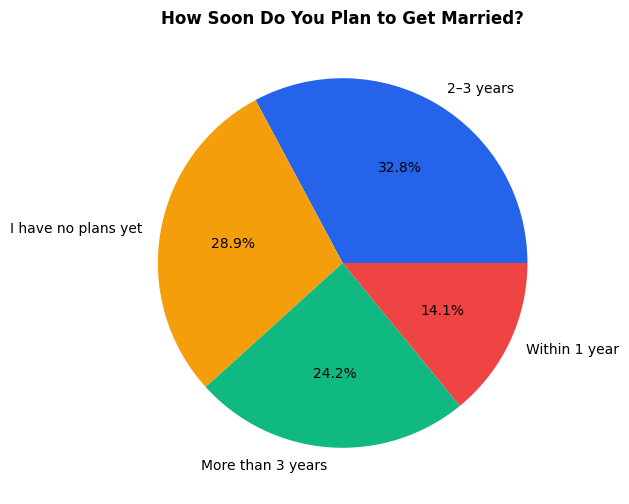

In [27]:
import os
os.makedirs('charts', exist_ok=True)
colors = ['#2563eb', '#f59e0b', '#10b981', '#ef4444', '#8b5cf6', '#ec4899']

# Chart 1: Marriage Timeline
fig, ax = plt.subplots(figsize=(8, 6))
vc = df['Q1_Marriage_Timeline'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors[:len(vc)])
ax.set_title('How Soon Do You Plan to Get Married?', fontweight='bold')
plt.savefig('charts/chart1_marriage_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

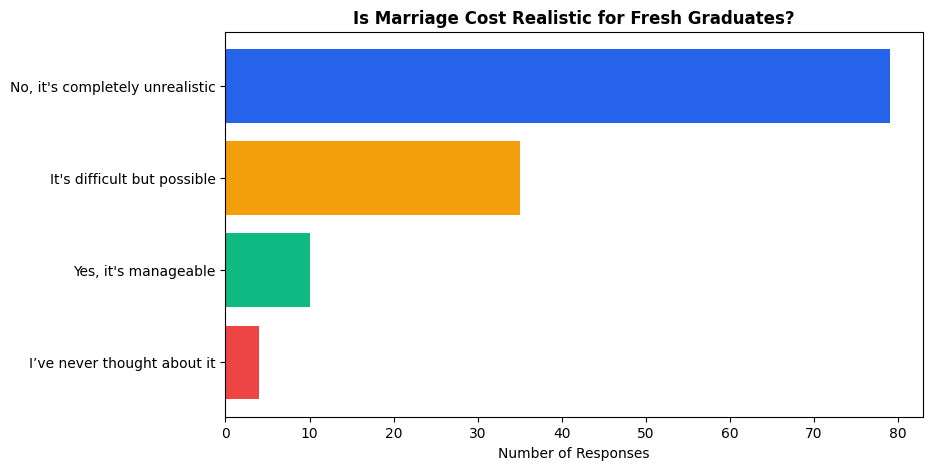

In [28]:
# Chart 2: Cost Realistic
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['Q2_Cost_Realistic'].value_counts()
ax.barh(vc.index, vc.values, color=colors[:len(vc)])
ax.set_xlabel('Number of Responses')
ax.set_title('Is Marriage Cost Realistic for Fresh Graduates?', fontweight='bold')
ax.invert_yaxis()
plt.savefig('charts/chart2_cost_realistic.png', dpi=150, bbox_inches='tight')
plt.show()

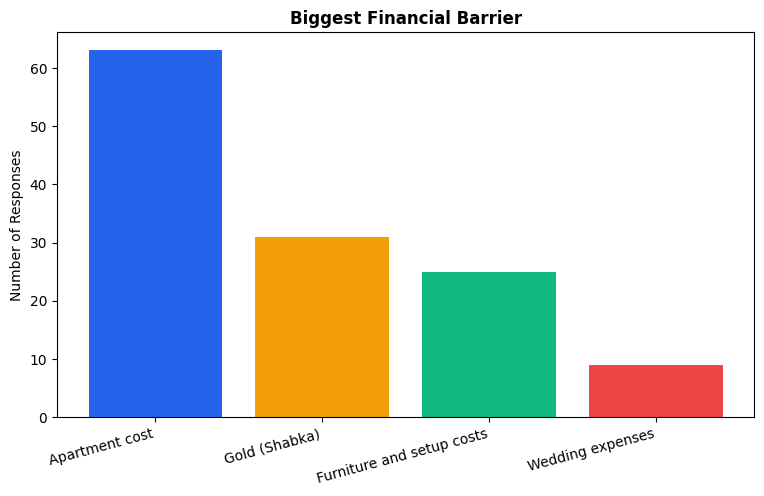

In [29]:
# Chart 3: Biggest Barrier
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['Q3_Biggest_Barrier'].value_counts()
ax.bar(vc.index, vc.values, color=colors[:len(vc)])
ax.set_ylabel('Number of Responses')
ax.set_title('Biggest Financial Barrier', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.savefig('charts/chart3_biggest_barrier.png', dpi=150, bbox_inches='tight')
plt.show()

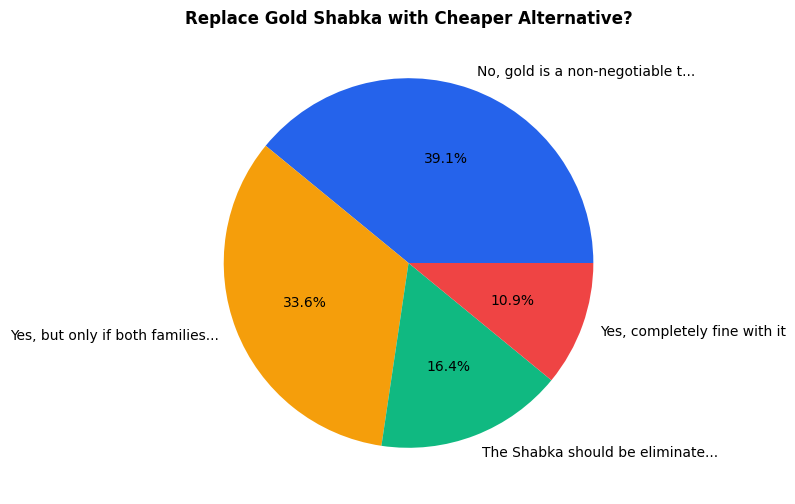

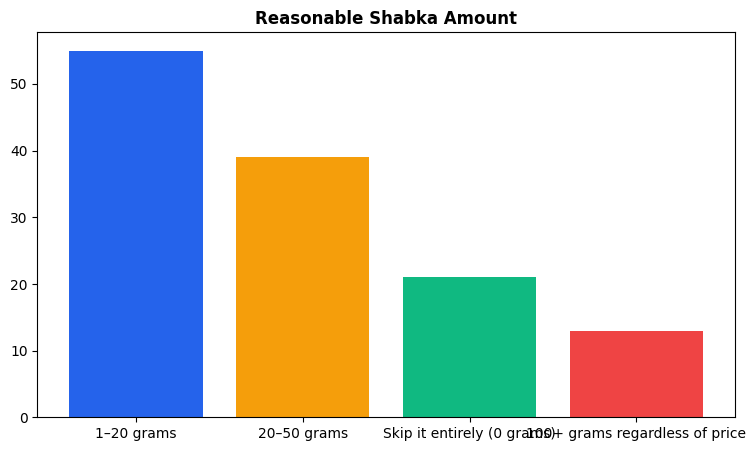

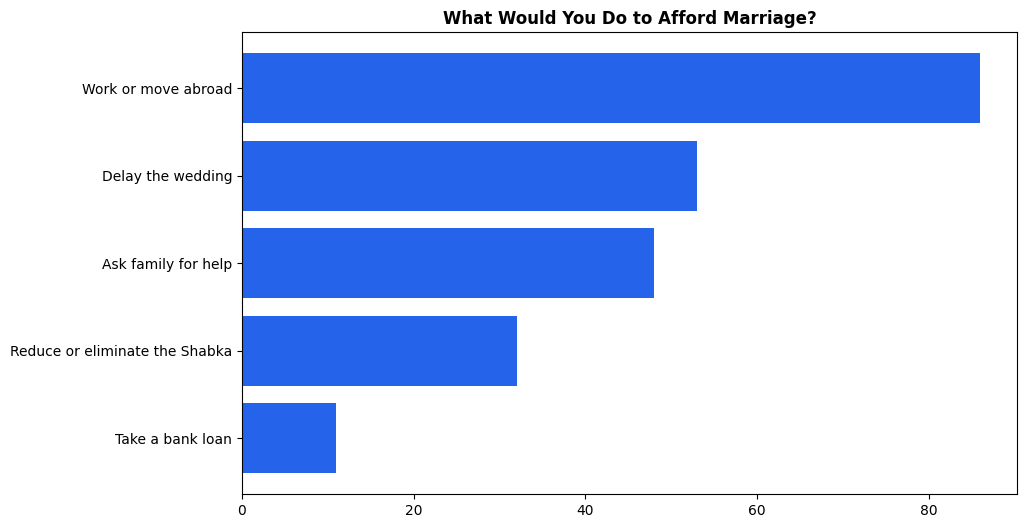

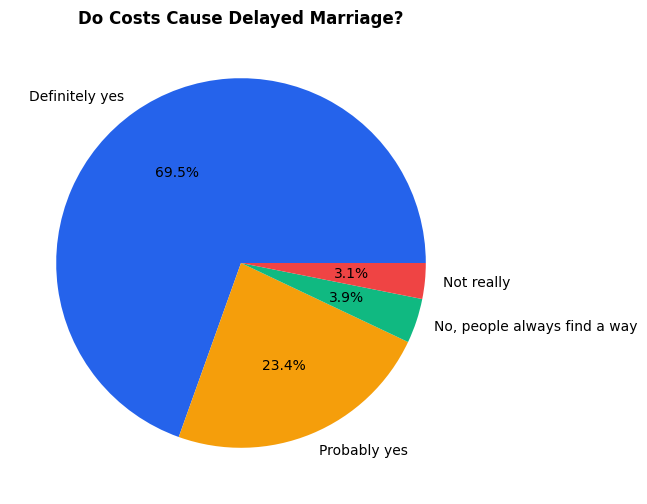

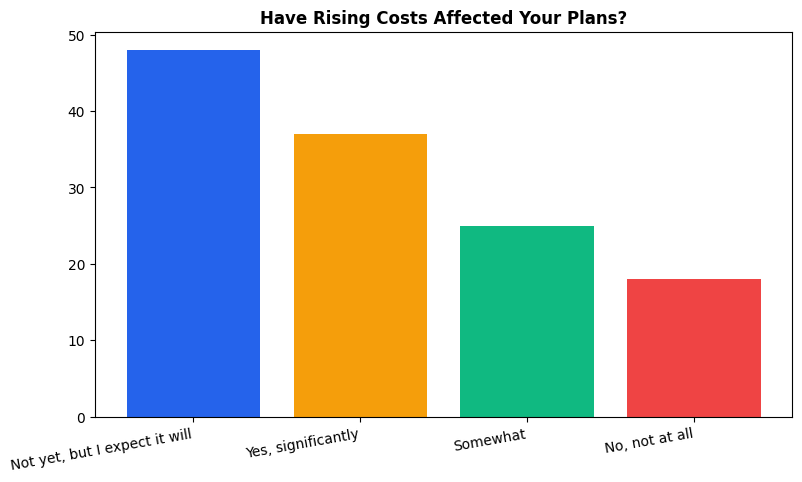

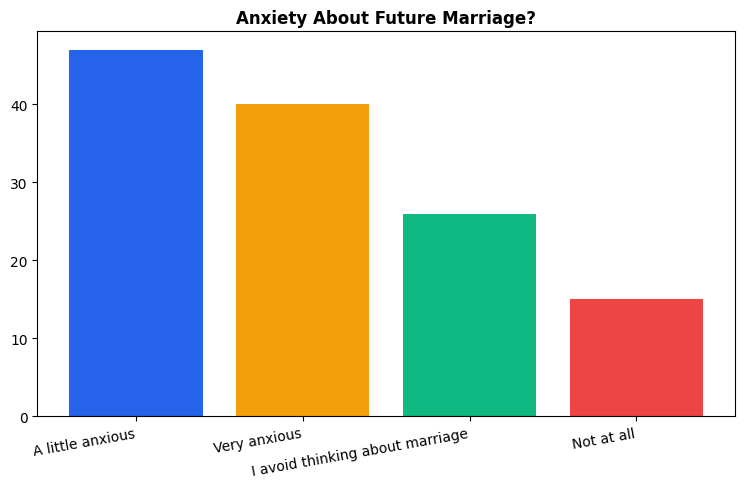

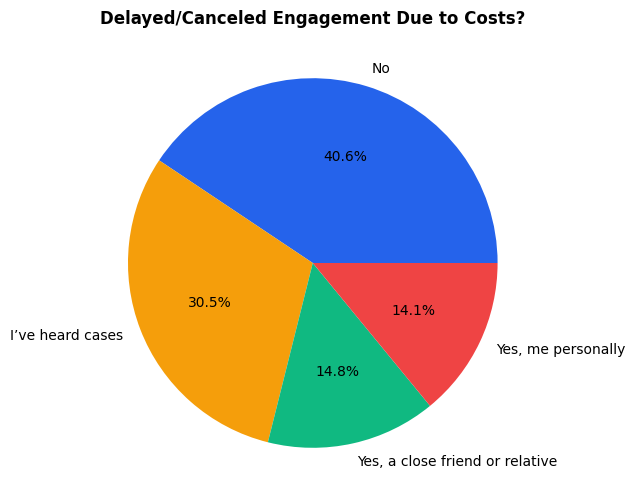

In [30]:
# Charts 4-10 follow the same pattern
# Chart 4: Replace Shabka
fig, ax = plt.subplots(figsize=(8, 6))
vc = df['Q4_Replace_Shabka'].value_counts()
ax.pie(vc.values, labels=[l[:30]+'...' if len(l)>30 else l for l in vc.index], autopct='%1.1f%%', colors=colors[:len(vc)])
ax.set_title('Replace Gold Shabka with Cheaper Alternative?', fontweight='bold')
plt.savefig('charts/chart4_replace_shabka.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 5: Reasonable Shabka
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['Q5_Reasonable_Shabka'].value_counts()
ax.bar(vc.index, vc.values, color=colors[:len(vc)])
ax.set_title('Reasonable Shabka Amount', fontweight='bold')
plt.savefig('charts/chart5_reasonable_shabka.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 6: Willing to Do
fig, ax = plt.subplots(figsize=(10, 6))
opts = {}
for val in df['Q6_Willing_To_Do'].dropna():
    for p in str(val).split(','):
        p = p.strip()
        opts[p] = opts.get(p, 0) + 1
oc = pd.Series(opts).sort_values(ascending=True)
ax.barh(oc.index, oc.values, color='#2563eb')
ax.set_title('What Would You Do to Afford Marriage?', fontweight='bold')
plt.savefig('charts/chart6_willing_to_do.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 7: Costs Cause Delay
fig, ax = plt.subplots(figsize=(8, 6))
vc = df['Q7_Costs_Cause_Delay'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors[:len(vc)])
ax.set_title('Do Costs Cause Delayed Marriage?', fontweight='bold')
plt.savefig('charts/chart7_costs_delay.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 8: Personally Affected
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['Q8_Personally_Affected'].value_counts()
ax.bar(vc.index, vc.values, color=colors[:len(vc)])
ax.set_title('Have Rising Costs Affected Your Plans?', fontweight='bold')
plt.xticks(rotation=10, ha='right')
plt.savefig('charts/chart8_personally_affected.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 9: Anxiety
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['Q9_Anxiety'].value_counts()
ax.bar(vc.index, vc.values, color=colors[:len(vc)])
ax.set_title('Anxiety About Future Marriage?', fontweight='bold')
plt.xticks(rotation=10, ha='right')
plt.savefig('charts/chart9_anxiety.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 10: Delayed Engagement
fig, ax = plt.subplots(figsize=(8, 6))
vc = df['Q10_Delayed_Engagement'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=colors[:len(vc)])
ax.set_title('Delayed/Canceled Engagement Due to Costs?', fontweight='bold')
plt.savefig('charts/chart10_delayed_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Done
All charts saved to `charts/` folder. Clean data saved as `clean_data.csv`.